# Assignment 1 2AMM10 2025-2026

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

In [15]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

# Task 1

In [16]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

<Axes: >

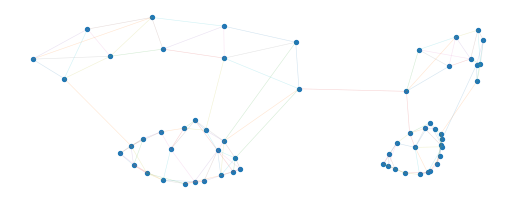

In [17]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

In [18]:

from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.loader import DataLoader
import torch.nn.functional as F


class GraphSAGE(nn.Module):
    """
    GraphSAGE model for graph-level binary classification (awake vs drowsy).

    Architecture (Geometric Deep Learning blueprint):
        [SAGEConv → BN → ReLU → Dropout] × num_layers   # equivariant layers
        → global_mean_pool                                # invariant global pooling
        → MLP head (Linear → ReLU → Dropout → Linear)    # binary classifier

    SAGEConv update rule (mean variant):
        x_i^(k) = W1 * x_i^(k-1)  +  (1/|N(i)|) * Σ_{j ∈ N(i)} x_j^(k-1)

    Parameter re-use across all nodes makes the layer permutation-equivariant.
    Mean aggregation over N(i) is permutation-invariant (nodes have no canonical ordering).

    Output: scalar logit per graph (positive = drowsy).
            Use BCEWithLogitsLoss during training; sigmoid ≥ 0.5 at inference.
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int = 64,
        num_layers: int = 3,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # First layer: in_channels → hidden_channels
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Remaining GNN layers: hidden_channels → hidden_channels
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # MLP classification head (maps graph embedding → scalar logit)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1),  # scalar output; BCEWithLogitsLoss applies sigmoid
        )

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch: torch.Tensor):
        # Equivariant message-passing layers
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Invariant global pooling: collapse node embeddings into one graph embedding
        x = global_mean_pool(x, batch)  # [num_graphs, hidden_channels]

        # Binary classification head
        return self.mlp(x).squeeze(-1)  # [num_graphs]  (scalar logit per graph)


In [19]:

# ── DataLoaders ──────────────────────────────────────────────────────────────
train_dataset_graph = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset_graph  = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")

BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset_graph, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset_graph,  batch_size=BATCH_SIZE, shuffle=False)

# ── Model, optimiser ─────────────────────────────────────────────────────────
IN_CHANNELS     = train_dataset_graph[0].x.shape[1]  # 3 (x, y, z coordinates)
HIDDEN_CHANNELS = 64    # smaller width reduces overfitting on 400-sample dataset
NUM_LAYERS      = 3
DROPOUT         = 0.3
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
EPOCHS          = 100   # more epochs; cosine LR decays slowly, best checkpoint saved

model     = GraphSAGE(IN_CHANNELS, HIDDEN_CHANNELS, NUM_LAYERS, DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters : {total_params:,}")
print(f"Training samples     : {len(train_dataset_graph)}")
print(f"Test samples         : {len(test_dataset_graph)}")
print(f"Node features        : {IN_CHANNELS}")
print(f"Classes              : {train_dataset_graph.id_to_class}")
print(f"Device               : {DEVICE}")


GraphSAGE(
  (convs): ModuleList(
    (0): SAGEConv(3, 64, aggr=mean)
    (1-2): 2 x SAGEConv(64, 64, aggr=mean)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters : 19,457
Training samples     : 400
Test samples         : 100
Node features        : 3
Classes              : {'0': 'awake', '1': 'drowsy'}
Device               : mps


In [20]:

# ── Helper functions ─────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, device):
    """One training epoch using BCEWithLogitsLoss (numerically stable binary CE)."""
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        # Labels must be float for BCEWithLogitsLoss
        loss = F.binary_cross_entropy_with_logits(logits, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    """
    Returns (loss, recall, precision) for the positive class (drowsy=1).

    Recall    = TP / (TP + FN)  — fraction of truly drowsy drivers detected.
                Critical in safety-critical driving: a missed drowsy driver
                (FN) prevents a safety alarm from triggering.
    Precision = TP / (TP + FP)  — fraction of drowsy predictions that are correct.

    Task requirement: both metrics must reach ≥ 0.6 on the test set.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        total_loss += F.binary_cross_entropy_with_logits(logits, batch.y.float()).item() * batch.num_graphs
        preds = (torch.sigmoid(logits) >= 0.5).long()
        all_preds.append(preds.cpu())
        all_labels.append(batch.y.cpu())

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    TP = ((all_preds == 1) & (all_labels == 1)).sum().item()
    FP = ((all_preds == 1) & (all_labels == 0)).sum().item()
    FN = ((all_preds == 0) & (all_labels == 1)).sum().item()

    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    avg_loss  = total_loss / len(loader.dataset)

    return avg_loss, recall, precision


# ── Training loop ─────────────────────────────────────────────────────────────
best_recall   = 0.0
train_losses  = []
test_losses   = []
test_recalls  = []
test_precs    = []

for epoch in range(1, EPOCHS + 1):
    train_loss              = train_epoch(model, train_loader, optimizer, DEVICE)
    test_loss, recall, prec = evaluate(model, test_loader, DEVICE)
    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_recalls.append(recall)
    test_precs.append(prec)

    # Save best checkpoint based on recall (most safety-critical metric)
    if recall > best_recall:
        best_recall = recall
        torch.save(model.state_dict(), "model_task1_sage.pth")

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{EPOCHS}  |  "
            f"Train Loss: {train_loss:.4f}  |  "
            f"Test Loss: {test_loss:.4f}  |  "
            f"Recall: {recall:.4f}  |  "
            f"Precision: {prec:.4f}"
        )

print(f"\nBest test recall: {best_recall:.4f}")

# ── Final evaluation with best checkpoint ────────────────────────────────────
model.load_state_dict(torch.load("model_task1_sage.pth", weights_only=True))
_, final_recall, final_prec = evaluate(model, test_loader, DEVICE)

print("\n── Final Test Set Results ───────────────────────────────────")
print(f"  Recall    (TP/(TP+FN)): {final_recall:.4f}  {'✓ >= 0.6' if final_recall >= 0.6 else '✗ < 0.6'}")
print(f"  Precision (TP/(TP+FP)): {final_prec:.4f}  {'✓ >= 0.6' if final_prec >= 0.6 else '✗ < 0.6'}")
print("─────────────────────────────────────────────────────────────")


Epoch   1/100  |  Train Loss: 0.6727  |  Test Loss: 0.6902  |  Recall: 0.1000  |  Precision: 0.3125
Epoch  10/100  |  Train Loss: 0.4600  |  Test Loss: 0.4966  |  Recall: 0.6800  |  Precision: 0.7727
Epoch  20/100  |  Train Loss: 0.3982  |  Test Loss: 0.4181  |  Recall: 0.5800  |  Precision: 1.0000
Epoch  30/100  |  Train Loss: 0.3776  |  Test Loss: 0.4193  |  Recall: 0.6000  |  Precision: 0.9375
Epoch  40/100  |  Train Loss: 0.3411  |  Test Loss: 0.3864  |  Recall: 0.6200  |  Precision: 0.9688
Epoch  50/100  |  Train Loss: 0.3584  |  Test Loss: 0.3655  |  Recall: 0.6600  |  Precision: 0.9167
Epoch  60/100  |  Train Loss: 0.3360  |  Test Loss: 0.3505  |  Recall: 0.7800  |  Precision: 0.9512
Epoch  70/100  |  Train Loss: 0.3118  |  Test Loss: 0.3467  |  Recall: 0.8200  |  Precision: 0.9318
Epoch  80/100  |  Train Loss: 0.3290  |  Test Loss: 0.3376  |  Recall: 0.8200  |  Precision: 0.9318
Epoch  90/100  |  Train Loss: 0.3151  |  Test Loss: 0.3325  |  Recall: 0.8200  |  Precision: 0.9318


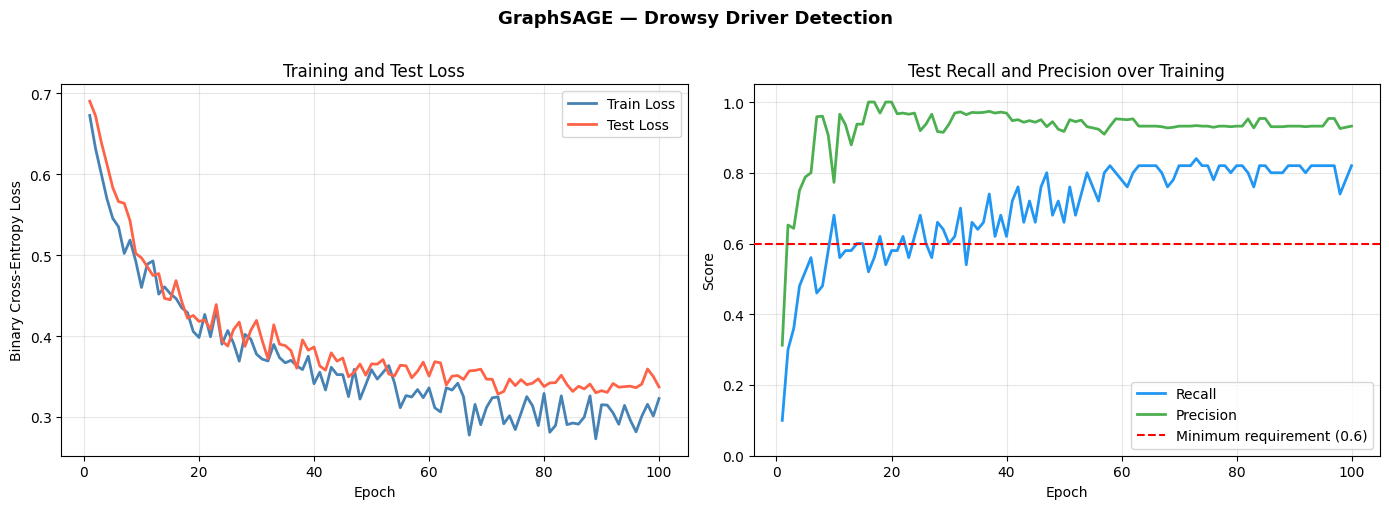

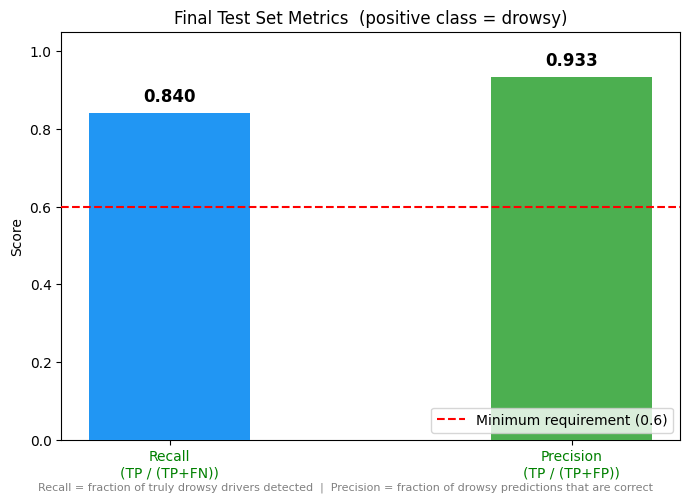

In [21]:

# ── Training curves ────────────────────────────────────────────────────────────
# Run this cell independently to regenerate plots without retraining.

ep = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Loss curves ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(ep, train_losses, label="Train Loss", color="steelblue", linewidth=2)
ax.plot(ep, test_losses,  label="Test Loss",  color="tomato",    linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.set_title("Training and Test Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Right: Recall and Precision over epochs ────────────────────────────────────
ax = axes[1]
ax.plot(ep, test_recalls, label="Recall",    color="#2196F3", linewidth=2)
ax.plot(ep, test_precs,   label="Precision", color="#4CAF50", linewidth=2)
ax.axhline(0.6, color="red", linestyle="--", linewidth=1.5,
           label="Minimum requirement (0.6)", zorder=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Test Recall and Precision over Training")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("GraphSAGE — Drowsy Driver Detection", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Bar chart: final Recall vs Precision ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
names  = ["Recall\n(TP / (TP+FN))", "Precision\n(TP / (TP+FP))"]
values = [final_recall, final_prec]
colors = ["#2196F3", "#4CAF50"]

bars = ax.bar(names, values, color=colors, width=0.4, zorder=3)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.axhline(0.6, color="red", linestyle="--", linewidth=1.5,
           label="Minimum requirement (0.6)", zorder=4)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Final Test Set Metrics  (positive class = drowsy)")
ax.legend(loc="lower right")

for tick, val in zip(ax.get_xticklabels(), values):
    tick.set_color("green" if val >= 0.6 else "red")

fig.text(0.5, 0.01,
         "Recall = fraction of truly drowsy drivers detected  |  "
         "Precision = fraction of drowsy predictions that are correct",
         ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("test_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


# Task 2

In [22]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

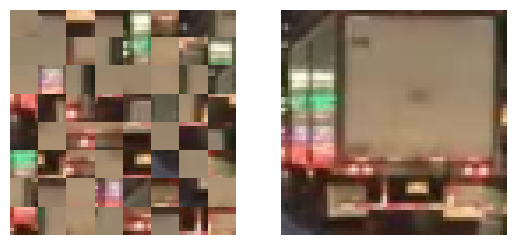

In [23]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

In [24]:
#transforms for training and testing (including patch shuffle for corrupted)
from torchvision.transforms import (
    Compose,
    Resize,
    ToTensor,
    Normalize,
    RandomRotation,
    ColorJitter,
)

train_transform = Compose([
    Resize((64, 64)),
    RandomRotation(10),
    ColorJitter(brightness=0.2, contrast=0.2),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = Compose([
    Resize((64, 64)),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

corrupted_transform = Compose([
    Resize((64, 64)),
    ToTensor(),
    PatchShuffle(patch_size=8),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [25]:
#Split dataset for training and validation, and create test datasets for clean and corrupted images

print("\nCreating datasets...")

train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=train_transform,
)

# Split train into train/validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_split, _ = torch.utils.data.random_split(
    train_dataset,
    [train_size, val_size],
)

# Validation datasets
val_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=test_transform,
)

val_corrupted = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=corrupted_transform,
)

# Test datasets
test_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=test_transform,
)

test_corrupted = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=corrupted_transform,
)


Creating datasets...


In [26]:
# data loaderrs
from torch.utils.data import Dataset, DataLoader
train_loader = DataLoader(
    train_split,
    batch_size=16,
    shuffle=True,
    num_workers=0,
)

val_loader_clean = DataLoader(
    val_clean,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

val_loader_corrupted = DataLoader(
    val_corrupted,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

test_loader_clean = DataLoader(
    test_clean,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

test_loader_corrupted = DataLoader(
    test_corrupted,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

In [ ]:
#split images into 64 pieces internally
#train on them 
#test if the model can predict the correct label from the shuffled image
#to train it, the structure of the 9 pieces that intersect one image arethe same so try to cluster them together



class PatchEmbedding(nn.Module):
    """
    Extract features from individual patches.    
    Process:
    1. Divide image into non-overlapping 8x8 patches
    2. Embed each patch through a CNN
    3. Output: [num_patches, embedding_dim]
    """
    
    def __init__(self, patch_size=8, embedding_dim=128):
        super(PatchEmbedding, self).__init__()
        self.patch_size = patch_size
        self.embedding_dim = embedding_dim
        
        # Small CNN for single patch (3×8×8 → embedding_dim)
        self.patch_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))  # Global pooling for single patch
        )
        
        self.fc = nn.Linear(64, embedding_dim)
    
    def forward(self, x):
        batch_size = x.size(0)
        patch_size = self.patch_size
        
        # Extract patches
        patches_list = []
        
        for y in range(0, x.size(2), patch_size):
            for x_pos in range(0, x.size(3), patch_size):
                patch = x[:, :, y:y+patch_size, x_pos:x_pos+patch_size]
                patches_list.append(patch)
        
        # Embed each patch
        patch_embeddings = []
        for patch in patches_list:
            # patch: [batch, 3, 8, 8]
            patch_feat = self.patch_cnn(patch)  # [batch, 64, 1, 1]
            patch_feat = patch_feat.squeeze(-1).squeeze(-1)  # [batch, 64]
            patch_emb = self.fc(patch_feat)  # [batch, embedding_dim]
            patch_embeddings.append(patch_emb)
        
        # Stack: [batch, num_patches, embedding_dim]
        patch_embeddings = torch.stack(patch_embeddings, dim=1)
        
        return patch_embeddings
    

class PatchAttentionAlignment(nn.Module):
    """
    Learn which patches should be neighbors in original image.
    """
    
    def __init__(self, embedding_dim=128, num_patches=1024, grid_size=32):
        super(PatchAttentionAlignment, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_patches = num_patches
        self.grid_size = grid_size  # 32x32 = 1024 patches
        
        # Multi-head attention for patch alignment
        self.attention = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=8,
            batch_first=True,
            dropout=0.1
        )
        
        # Refinement layers
        self.refine = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, embedding_dim)
        )
        
        # Spatial confidence (how confident are we about patch position?)
        self.spatial_confidence = nn.Sequential(
            nn.Linear(embedding_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()  # [0, 1] confidence scores
        )
    
    def forward(self, patch_embeddings):
        """
        Args:
            patch_embeddings: [batch, num_patches, embedding_dim]
        
        Returns:
            aligned_embeddings: [batch, num_patches, embedding_dim]
            spatial_weights: [batch, num_patches, 1]
        """
        batch_size = patch_embeddings.size(0)
        num_patches = patch_embeddings.size(1)
        
        # Self-attention: allow patches to communicate with neighbors
        # This reconstructs which patches "should" be together
        attn_out, _ = self.attention(
            patch_embeddings, patch_embeddings, patch_embeddings
        )
        
        # Residual connection + refinement
        refined = patch_embeddings + attn_out  # [batch, num_patches, embedding_dim]
        refined = refined + self.refine(refined)
        
        # Compute spatial confidence for each patch
        spatial_weights = self.spatial_confidence(refined)  # [batch, num_patches, 1]
        
        return refined, spatial_weights

In [28]:
class PatchInvariantClassifier(nn.Module):
    """
    Combine previous classes to build the classifier
    """
    
    def __init__(self, num_classes=8, patch_size=8, 
                 embedding_dim=128, grid_size=32):
        super(PatchInvariantClassifier, self).__init__()
        
        self.patch_size = patch_size
        self.embedding_dim = embedding_dim
        self.grid_size = grid_size
        self.num_patches = grid_size * grid_size
        self.num_classes = num_classes
        
        # Stage 1: Extract patch-independent features
        self.patch_embedding = PatchEmbedding(
            patch_size=patch_size,
            embedding_dim=embedding_dim
        )
        
        # Stage 2: Reconstruct spatial relationships
        self.attention_alignment = PatchAttentionAlignment(
            embedding_dim=embedding_dim,
            num_patches=self.num_patches,
            grid_size=grid_size
        )
        
        # Stage 3: Permutation-invariant aggregation
        # Instead of global pooling, use weighted pooling
        self.aggregation = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        
        # Stage 4: Classification
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        """
        Args:
            x: [batch, 3, 256, 256]
        
        Returns:
            logits: [batch, num_classes]
        """
        # Get patch embeddings
        patch_emb = self.patch_embedding(x)  # [batch, num_patches, embedding_dim]
        
        # Reconstruct spatial relationships
        aligned_emb, spatial_weights = self.attention_alignment(patch_emb)
        # aligned_emb: [batch, num_patches, embedding_dim]
        # spatial_weights: [batch, num_patches, 1]
        
        # Weighted aggregation (permutation-invariant)
        # Multiply embeddings by spatial weights
        weighted_emb = aligned_emb * spatial_weights  # [batch, num_patches, embedding_dim]
        
        # Aggregate with weighted sum
        aggregated = weighted_emb.sum(dim=1)  # [batch, embedding_dim]
        aggregated = aggregated / (spatial_weights.sum(dim=1) + 1e-8)
        refined = self.aggregation(aggregated)  # [batch, 128]
        logits = self.classifier(refined)  # [batch, num_classes]
        
        return logits

In [33]:
from collections import defaultdict
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

def evaluate(self, predictions, targets, stage='test'):
    """
    Multi-class evaluation (8 classes).

    Computes:
        - precision per class
        - recall per class
    """

    pred_labels = predictions.argmax(dim=1).cpu().numpy()
    targets_np = targets.squeeze().cpu().numpy()

    # per-class metrics
    precision, recall, _, _ = precision_recall_fscore_support(
        targets_np,
        pred_labels,
        labels=list(range(8)),
        average=None,
        zero_division=0
    )

    metrics = {}

    # store per-class metrics
    for c in range(8):
        metrics[f'{stage}_precision_class_{c}'] = precision[c]
        metrics[f'{stage}_recall_class_{c}'] = recall[c]

        self.metrics[f'{stage}_precision_class_{c}'].append(precision[c])
        self.metrics[f'{stage}_recall_class_{c}'].append(recall[c])

    # ALSO store macro averages (for plotting convenience)
    metrics[f'{stage}_precision'] = np.mean(precision)
    metrics[f'{stage}_recall'] = np.mean(recall)

    self.metrics[f'{stage}_precision'].append(metrics[f'{stage}_precision'])
    self.metrics[f'{stage}_recall'].append(metrics[f'{stage}_recall'])

    return metrics, pred_labels, targets_np

class RobustnessEvaluator:
    """Evaluate model robustness to patch shuffling corruption."""
    
    def __init__(self):
        self.metrics = defaultdict(list)

    def evaluate(self, predictions, targets, stage='test'):
        """
        Multi-class evaluation (8 classes).

        Computes:
            - precision per class
            - recall per class
        """

        pred_labels = predictions.argmax(dim=1).cpu().numpy()
        targets_np = targets.squeeze().cpu().numpy()

        # per-class metrics
        precision, recall, _, _ = precision_recall_fscore_support(
            targets_np,
            pred_labels,
            labels=list(range(8)),
            average=None,
            zero_division=0
        )

        metrics = {}

        # store per-class metrics
        for c in range(8):
            metrics[f'{stage}_precision_class_{c}'] = precision[c]
            metrics[f'{stage}_recall_class_{c}'] = recall[c]

            self.metrics[f'{stage}_precision_class_{c}'].append(precision[c])
            self.metrics[f'{stage}_recall_class_{c}'].append(recall[c])

        # ALSO store macro averages (for plotting convenience)
        metrics[f'{stage}_precision'] = np.mean(precision)
        metrics[f'{stage}_recall'] = np.mean(recall)

        self.metrics[f'{stage}_precision'].append(metrics[f'{stage}_precision'])
        self.metrics[f'{stage}_recall'].append(metrics[f'{stage}_recall'])

        return metrics, pred_labels, targets_np
    
    def print_report(self, stage='test'):
        print(f"\n{'='*60}")
        print(f"{stage.upper()} REPORT")
        print(f"{'='*60}")

        recall = self.metrics[f'{stage}_recall'][-1]
        precision = self.metrics[f'{stage}_precision'][-1]

        print(f"Recall:    {recall:.4f}")
        print(f"Precision: {precision:.4f}")
    

In [38]:
import copy

import torch.optim as optim

def train_model(model, train_loader, val_loader_clean, val_loader_corrupted,
                test_loader_clean, test_loader_corrupted,
                epochs=30, lr=0.001):
    """
    Train model with early stopping based on corrupted validation set.
    We optimize on CLEAN training data but validate on CORRUPTED data.
    """
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    evaluator = RobustnessEvaluator()
    
    best_corrupted_recall = 0
    patience = 10
    patience_counter = 0
    train_losses = []
    val_losses = []
    val_recalls = []
    val_precs = []

    print(f"Device: {device}")
    print(f"Model Parameters: {sum(p.numel() for p in model.parameters())}")
    best_model_state = copy.deepcopy(model.state_dict())
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation on CLEAN data
        model.eval()
        with torch.no_grad():
            clean_loss = 0.0
            clean_preds = []
            clean_targets = []

            for images, labels in val_loader_clean:
                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)

                clean_loss += criterion(logits, labels).item()

                clean_preds.append(logits.cpu())
                clean_targets.append(labels.cpu())

            clean_loss /= len(val_loader_clean)

            clean_preds = torch.cat(clean_preds)
            clean_targets = torch.cat(clean_targets)

            clean_metrics, _, _ = evaluator.evaluate(
                clean_preds,
                clean_targets,
                stage="clean"
            )
            train_losses.append(train_loss)
            val_losses.append(clean_loss)

            val_recalls.append(clean_metrics["clean_recall"])
            val_precs.append(clean_metrics["clean_precision"])
        
        # Validation on CORRUPTED data
        with torch.no_grad():
            corrupted_preds = []
            corrupted_targets = []
            
            for images, labels in val_loader_corrupted:
                images = images.to(device)
                logits = model(images)
                corrupted_preds.append(logits.cpu())
                corrupted_targets.append(labels)
            
            corrupted_preds = torch.cat(corrupted_preds, dim=0)
            corrupted_targets = torch.cat(corrupted_targets, dim=0)
            corrupted_metrics, _, _ = evaluator.evaluate(
                corrupted_preds, corrupted_targets, stage='corrupted'
            )
        
        # Early stopping based on CORRUPTED validation accuracy
        if corrupted_metrics['corrupted_recall'] > best_corrupted_recall:
            best_corrupted_recall = corrupted_metrics['corrupted_recall']
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        print(f"\nEpoch {epoch+1}/{epochs}")
        if (epoch + 1) % 5 == 0:
            print(f"  Train Loss:        {train_loss:.4f}")
            print(f"  Clean Val Acc:     {clean_metrics['clean_recall']:.4f}")
            print(f"  Corrupted Val Acc: {corrupted_metrics['corrupted_recall']:.4f}")
        
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    # Final evaluation
    print("FINAL EVALUATION")
    
    model.eval()
    with torch.no_grad():
        # Clean test set
        clean_test_preds = []
        clean_test_targets = []
        for images, labels in test_loader_clean:
            images = images.to(device)
            logits = model(images)
            clean_test_preds.append(logits.cpu())
            clean_test_targets.append(labels)
        
        clean_test_preds = torch.cat(clean_test_preds, dim=0)
        clean_test_targets = torch.cat(clean_test_targets, dim=0)
        clean_test_metrics, _, _ = evaluator.evaluate(
            clean_test_preds, clean_test_targets, stage='clean_test'
        )
        
        # Corrupted test set
        corrupted_test_preds = []
        corrupted_test_targets = []
        for images, labels in test_loader_corrupted:
            images = images.to(device)
            logits = model(images)
            corrupted_test_preds.append(logits.cpu())
            corrupted_test_targets.append(labels)
        
        corrupted_test_preds = torch.cat(corrupted_test_preds, dim=0)
        corrupted_test_targets = torch.cat(corrupted_test_targets, dim=0)
        corrupted_test_metrics, pred_labels, _ = evaluator.evaluate(corrupted_test_preds, corrupted_test_targets, stage='corrupted_test')
        # aggregated (macro) metrics for corrupted test set
        corrupt_macro_recall = corrupted_test_metrics['corrupted_test_recall']
        corrupt_macro_precision = corrupted_test_metrics['corrupted_test_precision']
        clean_macro_recall = clean_test_metrics['clean_test_recall']
        clean_macro_precision = clean_test_metrics['clean_test_precision']
        final_recall = corrupted_test_metrics["corrupted_test_recall"]
        final_prec = corrupted_test_metrics["corrupted_test_precision"]
    
    # Robustness metric
    clean_recall = clean_test_metrics['clean_test_recall']
    clean_precision = clean_test_metrics['clean_test_precision']

    corrupt_recall = corrupted_test_metrics['corrupted_test_recall']
    corrupt_precision = corrupted_test_metrics['corrupted_test_precision']
    
    print(f"Clean Test Recall:      {clean_recall:.4f}")
    print(f"Corrupted Test Recall:  {corrupt_recall:.4f}")
    print(f"Clean Test Precision:   {clean_precision:.4f}")
    print(f"Corrupted Test Precision: {corrupt_precision:.4f}")

    return (
    model,
    evaluator,
    train_losses,
    val_losses,
    val_recalls,
    val_precs,
    clean_macro_recall,
    clean_macro_precision,
    corrupt_macro_recall,
    corrupt_macro_precision,
)
 

In [39]:
if __name__ == "__main__":
    print("PATCH-INVARIANT OBJECT CLASSIFICATION")
    print("Robust to Hardware Sensor Corruption (8x8 Patch Shuffling)")
    
    train_split, val_split = torch.utils.data.random_split(
        train_dataset, [train_size, val_size]
    )
    print(f"Training samples: {len(train_split)}")
    print(f"Validation samples: {len(val_split)}")
    print(f"Test samples (clean): {len(test_clean)}")
    print(f"Test samples (corrupted): {len(test_corrupted)}")
    
    model = PatchInvariantClassifier(
    num_classes=train_dataset.num_classes,
    patch_size=8,
    embedding_dim=128,
    grid_size=8,
)
    
    trained_model, evaluator, train_losses, val_losses, val_recalls, val_precs, clean_macro_recall, clean_macro_precision, corrupt_macro_recall, corrupt_macro_precision = train_model(
        model,
        train_loader,
        val_loader_clean,
        val_loader_corrupted,
        test_loader_clean,
        test_loader_corrupted,
        epochs=30,
        lr=0.001
    )

PATCH-INVARIANT OBJECT CLASSIFICATION
Robust to Hardware Sensor Corruption (8x8 Patch Shuffling)
Training samples: 1920
Validation samples: 480
Test samples (clean): 240
Test samples (corrupted): 240
Device: cpu
Model Parameters: 251209

Epoch 1/30

Epoch 2/30

Epoch 3/30

Epoch 4/30

Epoch 5/30
  Train Loss:        1.8924
  Clean Val Acc:     0.2625
  Corrupted Val Acc: 0.2625

Epoch 6/30

Epoch 7/30

Epoch 8/30

Epoch 9/30

Epoch 10/30
  Train Loss:        1.8276
  Clean Val Acc:     0.2708
  Corrupted Val Acc: 0.2708

Epoch 11/30

Epoch 12/30

Epoch 13/30

Epoch 14/30

Epoch 15/30
  Train Loss:        1.8004
  Clean Val Acc:     0.2667
  Corrupted Val Acc: 0.2667

Epoch 16/30

Epoch 17/30

Epoch 18/30

Epoch 19/30

Epoch 20/30
  Train Loss:        1.7685
  Clean Val Acc:     0.2875
  Corrupted Val Acc: 0.2875

Epoch 21/30

Epoch 22/30

Epoch 23/30

Epoch 24/30

Epoch 25/30
  Train Loss:        1.7025
  Clean Val Acc:     0.3292
  Corrupted Val Acc: 0.3292

Epoch 26/30

Epoch 27/30



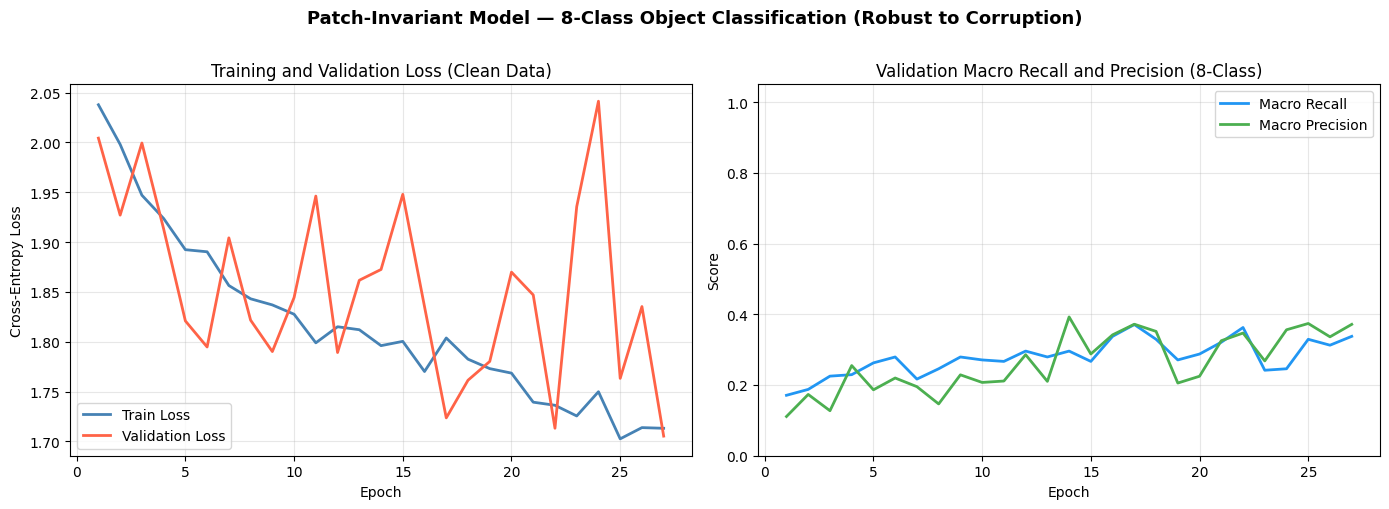

/var/folders/f7/s_x8b0p11k98grr_sgjv8mwh0000gn/T/ipykernel_6136/4135546597.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


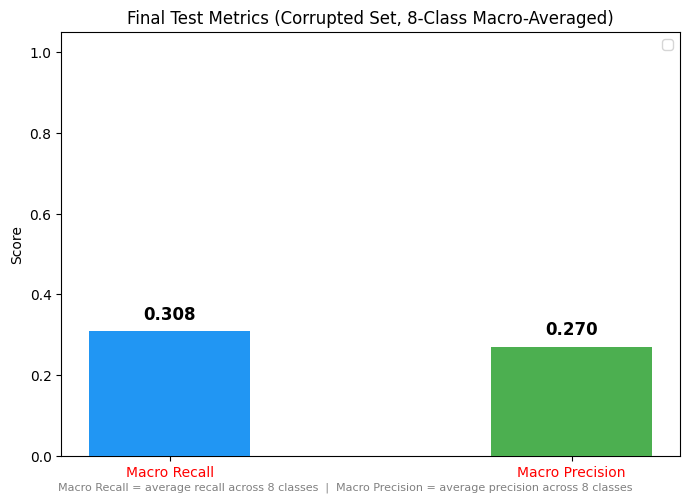

In [40]:
# ── Training curves (TASK 2: 8-class classification) ──────────────────────────

ep = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─────────────────────────────────────────────────────────────────────────────
# Left: Loss curves (clean training vs validation)
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[0]

ax.plot(
    ep,
    train_losses,
    label="Train Loss",
    color="steelblue",
    linewidth=2
)

ax.plot(
    ep,
    val_losses,
    label="Validation Loss",
    color="tomato",
    linewidth=2
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training and Validation Loss (Clean Data)")
ax.legend()
ax.grid(True, alpha=0.3)


# ─────────────────────────────────────────────────────────────────────────────
# Right: Macro Recall / Precision over epochs
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[1]

ax.plot(
    ep,
    val_recalls,
    label="Macro Recall",
    color="#2196F3",
    linewidth=2
)

ax.plot(
    ep,
    val_precs,
    label="Macro Precision",
    color="#4CAF50",
    linewidth=2
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Validation Macro Recall and Precision (8-Class)")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(
    "Patch-Invariant Model — 8-Class Object Classification (Robust to Corruption)",
    fontsize=13,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.savefig("training_curves_task2.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# FINAL METRICS BAR CHART (Clean vs Corrupted Test)
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))

names = [
    "Macro Recall",
    "Macro Precision"
]

values = [
    final_recall,
    final_prec
]

colors = ["#2196F3", "#4CAF50"]

bars = ax.bar(names, values, color=colors, width=0.4, zorder=3)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Final Test Metrics (Corrupted Set, 8-Class Macro-Averaged)")
ax.legend()

for tick, val in zip(ax.get_xticklabels(), values):
    tick.set_color("green" if val >= 0.5 else "red")

fig.text(
    0.5,
    0.01,
    "Macro Recall = average recall across 8 classes  |  Macro Precision = average precision across 8 classes",
    ha="center",
    fontsize=8,
    color="gray"
)

plt.tight_layout()
plt.savefig("test_metrics_task2.png", dpi=150, bbox_inches="tight")
plt.show()

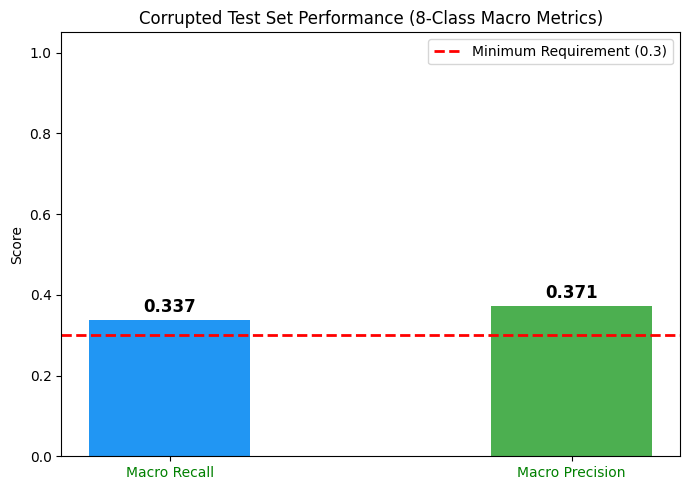

In [41]:
import matplotlib.pyplot as plt

baseline = 0.3

metrics_names = ["Macro Recall", "Macro Precision"]
values = [corrupt_macro_recall, corrupt_macro_precision]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(metrics_names, values, color=["#2196F3", "#4CAF50"], width=0.4)

# baseline line
ax.axhline(
    baseline,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Minimum Requirement (0.3)"
)

# value labels
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Corrupted Test Set Performance (8-Class Macro Metrics)")
ax.legend()

# color failure/success
for tick, val in zip(ax.get_xticklabels(), values):
    tick.set_color("green" if val >= baseline else "red")

plt.tight_layout()
plt.show()

# Task 2

In [ ]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()
        self.backbone = None  # Here you can use a function that creates the backbone model based on the backbone_arch string (take a look here: https://docs.pytorch.org/vision/main/models.html)

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.

        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.

        # TODO: define the trainable linear classification head
        self.linear_head = None

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        pass